In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime, date
from okx.store import OrderbookStore
import polars as pl

# Initialize the store
store = OrderbookStore(
    data_root="data/okx",
    manifest_path="data/okx/manifest.sqlite"
)

In [2]:
store.clear_cache()

Cleared all caches


In [4]:
store.populate(
    inst_type='SWAP',
    inst_family='BTC-USD',
    start=datetime(2025, 7, 1),
    end=datetime(2025, 11, 1),
    verbose=True,
    max_workers=10
)

Fetching BTC-USD/SWAP: 64 missing dates (from 123 requested)


  2025-08-07: No data returned from API
  2025-08-09: No data returned from API
✓ Stored 62/64 days as raw orderbook data
  Failed dates: [datetime.date(2025, 8, 7), datetime.date(2025, 8, 9)]


In [6]:
store.populate(
    inst_type='OPTION',
    inst_family='BTC-USD',
    start=datetime(2025, 9, 29),
    end=datetime(2025, 10, 2),
    verbose=True,
    max_workers=2
)

Fetching BTC-USD/OPTION: 2 missing dates (from 3 requested)


✓ Stored 2/2 days as raw orderbook data


In [5]:
# Store deletion example
# Example: Delete raw orderbook data for a specific family/type/date

# Let's delete one day's data for BTC-USD FUTURES (e.g. August 15, 2025)
delete_date = date(2025, 10, 1)

# uncomment to delete data
store.delete_raw('BTC-USD', 'OPTION', delete_date)

# You can check if it's deleted from the manifest:
have_after = store.manifest.have('BTC-USD', 'SPOT', delete_date, 'raw')
print(f"Raw for {delete_date} present after delete? {have_after}")


Raw for 2025-10-01 present after delete? True


In [ ]:
shared_params = {
    'inst_family': 'BTC-USD',
    'start': datetime(2025, 9, 1),
    'end': datetime(2025, 10, 1),
    'depth': 0,
    'binning': '10s',
    'features': ['spread','trim', 'strip', 'bin'],
    'verbose': True
}

spot_df = store.get(
    inst_type='SPOT',
    **shared_params
).collect()
swap_df = store.get(
    inst_type='SWAP',
    **shared_params
).collect()
futures_df = store.get(
    inst_type='FUTURES',
    **shared_params
).collect()

In [ ]:
def prepare_df(df, prefix):
    # Rename map: timeMs, bid_1_px, ask_1_px, mid => {prefix}_*
    rename_cols = ['timeMs', 'bid_1_px', 'ask_1_px', 'mid', 'spread']
    rename_map = {}
    for col in rename_cols:
        if col in df.columns:
            rename_map[col] = f'{prefix}_{col}'
    # Drop 'symbol' and rename columns
    return df.drop('symbol').rename(rename_map)

spot_df = prepare_df(spot_df, 'spot')
swap_df = prepare_df(swap_df, 'swap')

# Merge on 'time_bin' (outer join)
merged_df = spot_df.join(
    swap_df,
    on='time_bin',
    how='inner',
)

print(f"Merged shape: {merged_df.shape}")
print(merged_df.head())

diff: mean=-61.633248, median=-62.000000, std=12.103516


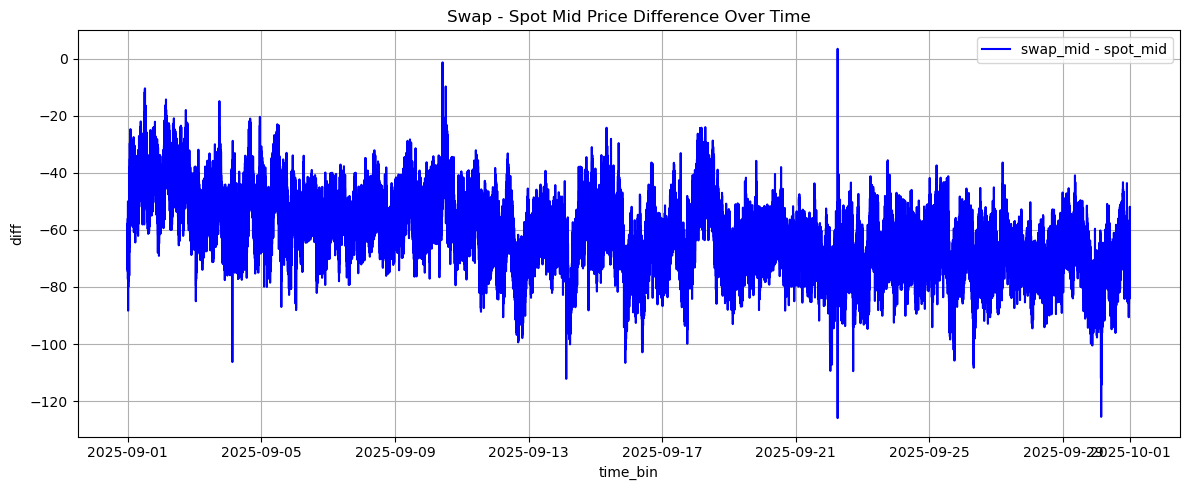

In [11]:
import matplotlib.pyplot as plt

merged_df = merged_df.with_columns(
    (merged_df['swap_mid'] - merged_df['spot_mid']).alias('diff')
)

# Compute statistics for merged_df['diff']
mean_diff = merged_df['diff'].mean()
median_diff = merged_df['diff'].median()
std_diff = merged_df['diff'].std()

print(f"diff: mean={mean_diff:.6f}, median={median_diff:.6f}, std={std_diff:.6f}")

# Plot: time_bin (datetime[ms]) as x axis, diff as y axis
fig, ax = plt.subplots(figsize=(12, 5))
# Make sure time_bin is sorted in ascending order for line plot
plot_df = merged_df.sort('time_bin')
ax.plot(plot_df['time_bin'].to_pandas(), plot_df['diff'].to_pandas(), label='swap_mid - spot_mid', color='blue')
ax.set_title('Swap - Spot Mid Price Difference Over Time')
ax.set_xlabel('time_bin')
ax.set_ylabel('diff')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(f"Shape: {df.shape}")
df.head()

In [ ]:
print(df['symbol'].unique())

In [ ]:
from utils import parse_option_name

# Since df is a Polars DataFrame (not a lazyframe at this point, since .collect() was called earlier), proceed accordingly.

# Analyze null count and percentage of each column
num_rows = df.height
nulls = df.null_count()
# Polars DataFrame returned by null_count() is a DataFrame, not a dict
# Convert to dict: use to_dict(as_series=False)[column_name][0]
nulls_dict = {col: nulls.select(col).to_series()[0] for col in df.columns}
nulls_pct = {col: (count / num_rows) * 100 for col, count in nulls_dict.items()}

# Display as a sorted table for readability, with both count and percentage
print("Null count and percentage per column:")
print(f"{'Column':<20} {'Nulls':>10} {'Pct':>8}")
for col in sorted(df.columns):
    count = nulls_dict[col]
    pct = nulls_pct[col]
    print(f"{col:<20} {count:10d} {pct:7.2f}%")

# Compute all unique option combos using parse_option_name
unique_symbols = df['symbol'].unique()
combos = set()
for sym in unique_symbols:
    # skip null/None values if present
    if sym is None:
        continue
    try:
        parsed = parse_option_name(sym)
        combo = (parsed[0], parsed[1], parsed[2])  # e.g. ('BTC-USD', expiry_datetime, strike)
        combos.add(combo)
    except Exception as e:
        print(f"Could not parse symbol '{sym}': {e}")

print("\nAll unique option combos (underlying, expiry, strike):")
for combo in sorted(combos, key=lambda x: (x[0], x[1], x[2])):
    print(combo)



In [ ]:
print(len(df))

In [ ]:
futures_df = store.get(
    inst_type='FUTURES',
    inst_family='BTC-USD',
    start=datetime(2025, 9, 1),
    end=datetime(2025, 10, 1),
    depth=0 
).collect()

In [ ]:
swap_df = store.get(
    inst_type='SWAP',
    inst_family='BTC-USD',
    start=datetime(2025, 9, 1),
    end=datetime(2025, 10, 1),
    depth=0 
).collect()

In [ ]:
unique_times_futures = set(futures_df['timeMs'].to_list())
unique_times_swap = set(swap_df['timeMs'].to_list())

In [ ]:
print(unique_times_futures - unique_times_swap)

In [ ]:
print(swap_df.shape)

In [ ]:
print(317425202 - 189060720)

In [ ]:
print(futures_df.head())

In [ ]:
class TestClass:
    def __init__(self, name: str):
        self.name = name

    def __str__(self):
        return f"TestClass: {self.name}"


In [ ]:
c = TestClass("test")
c.name = "test2"
print(c)